In [505]:
''' [0] Load Dataset '''
import numpy as np
import pandas as pd

train_df=pd.read_csv('ece657aw21-assignment1-iris-dataset/iris_train.csv')
test_df=pd.read_csv('ece657aw21-assignment1-iris-dataset/iris_test.csv')

In [506]:
''' [1] Overivew '''
# Force Display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# train_df.info()
train_df.describe()
# train_df.head()
# train_df.isna().sum()

,sepal_length,sepal_width,petal_length,petal_width
count,105.000000,101.000000,97.000000,105.000000
mean,5.858909,3.059083,3.812370,1.199708
std,0.861638,0.455116,1.793489,0.787193
min,4.344007,1.946010,1.033031,-0.072203
25%,5.159145,2.768688,1.545136,0.333494
50%,5.736104,3.049459,4.276817,1.331797
75%,6.435413,3.290318,5.094427,1.817211
max,7.795561,4.409565,6.768611,2.603123


In [507]:
''' [2] Data Cleaning '''
# print(train_df[train_df['sepal_width'].isna()])
# print(train_df[train_df['petal_length'].isna()])

train_df['sepal_width']=train_df['sepal_width'].fillna(train_df['sepal_width'].mean())
train_df['petal_length']=train_df['petal_length'].fillna(train_df['petal_length'].median())

test_df['sepal_width']=test_df['sepal_width'].fillna(test_df['sepal_width'].mean())
test_df['petal_length']=test_df['petal_length'].fillna(test_df['petal_length'].median())

In [508]:
''' [3] Calculate Upper & Lower Bounds (IQR) '''
Q1_petal_length=1.54
Q3_petal_length=5.1
IQR_petal_length=Q3_petal_length-Q1_petal_length

Q1_petal_width=0.3
Q3_petal_width=1.81
IQR_petal_width=Q3_petal_width-Q1_petal_width

Q1_sepal_width=2.76
Q3_sepal_width=3.29
IQR_sepal_width=Q3_sepal_width-Q1_sepal_width

lower_bound_petal_length=Q1_petal_length-1.5*IQR_petal_length
upper_bound_petal_length=Q3_petal_length+1.5*IQR_petal_length
lower_bound_petal_width=Q1_petal_width-1.5*IQR_petal_width
upper_bound_petal_width=Q3_petal_width+1.5*IQR_petal_width
lower_bound_sepal_width=Q1_sepal_width-1.5*IQR_sepal_width
upper_bound_sepal_width=Q3_sepal_width+1.5*IQR_sepal_width

print(
f"{lower_bound_petal_length}, {upper_bound_petal_length}, {lower_bound_petal_width}, {upper_bound_petal_width}, {lower_bound_sepal_width}, {upper_bound_sepal_width}"
)

-3.8, 10.44, -1.965, 4.075, 1.9649999999999994, 4.085000000000001


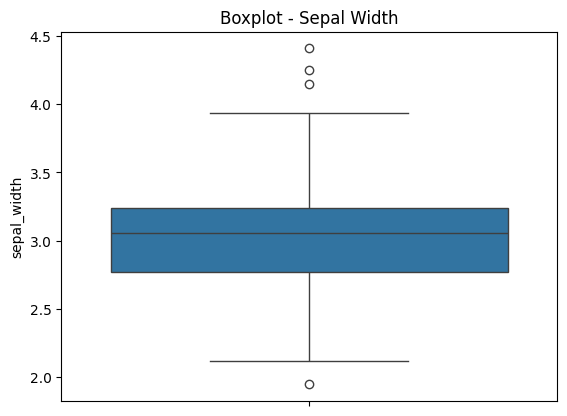

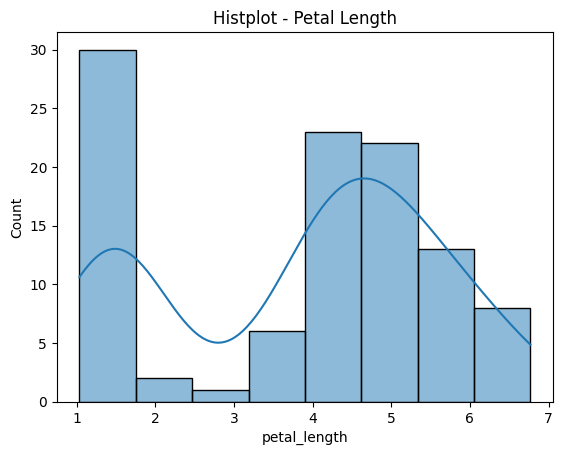

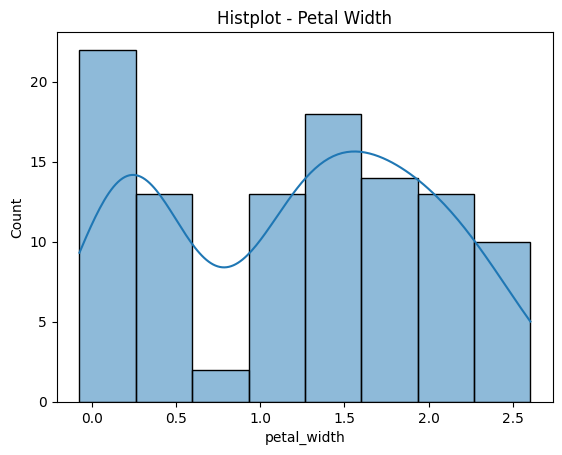

In [509]:
''' [4] Visualize Numeric Variables '''
import seaborn as sns
import matplotlib.pyplot as plt

# sns.histplot(train_df['sepal_length'], kde=True)
# plt.title('Histplot - Sepal Length')
# plt.show()

# sns.boxplot(train_df['sepal_length'])
# plt.title('Boxplot - Sepal Length')
# plt.show()

# sns.histplot(train_df['sepal_width'], kde=True)
# plt.title('Histplot - Sepal Width')
# plt.show()

sns.boxplot(train_df['sepal_width'])
plt.title('Boxplot - Sepal Width')
plt.show()

sns.histplot(train_df['petal_length'], kde=True)
plt.title('Histplot - Petal Length')
plt.show()

# sns.boxplot(train_df['petal_length'])
# plt.title('Boxplot - Petal Length')
# plt.show()

sns.histplot(train_df['petal_width'], kde=True)
plt.title('Histplot - Petal Width')
plt.show()

# sns.boxplot(train_df['petal_width'])
# plt.title('Boxplot - Petal Width')
# plt.show()

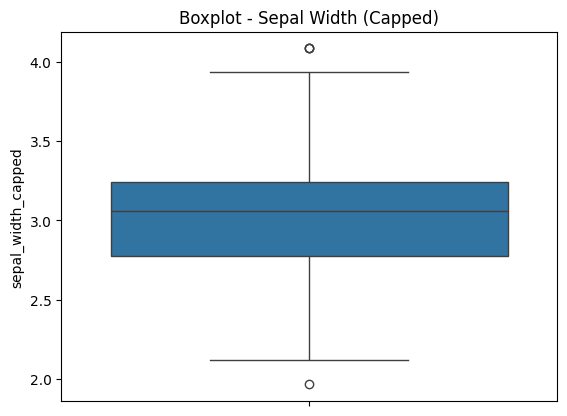

In [510]:
''' [5] Outliers '''
train_df['sepal_width_capped']=train_df['sepal_width'].clip(lower=lower_bound_sepal_width, upper=upper_bound_sepal_width)
test_df['sepal_width_capped']=test_df['sepal_width'].clip(lower=lower_bound_sepal_width, upper=upper_bound_sepal_width)

sns.boxplot(train_df['sepal_width_capped'])
plt.title("Boxplot - Sepal Width (Capped)")
plt.show()

In [511]:
''' [6] Distribution '''
from scipy.stats import skew

skewness_petal_length=skew(train_df['petal_length'])
skewness_petal_width=skew(train_df['petal_width'])

print(f"Skewness(Petal Length): {skewness_petal_length}")
print(f"Skewness(Petal Width): {skewness_petal_width}")

Skewness(Petal Length): -0.3202079149185206
Skewness(Petal Width): -0.0736790982420025


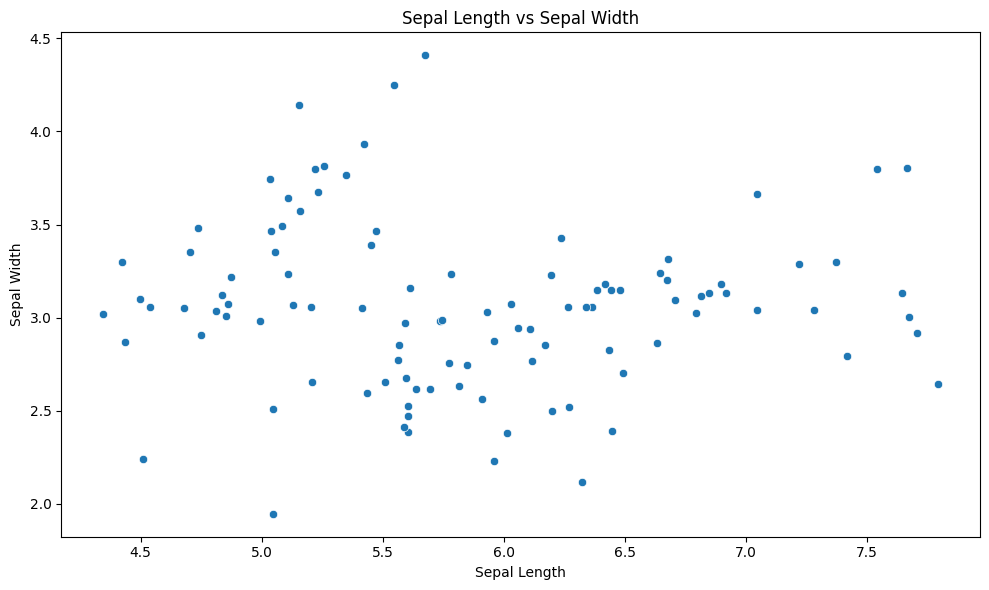

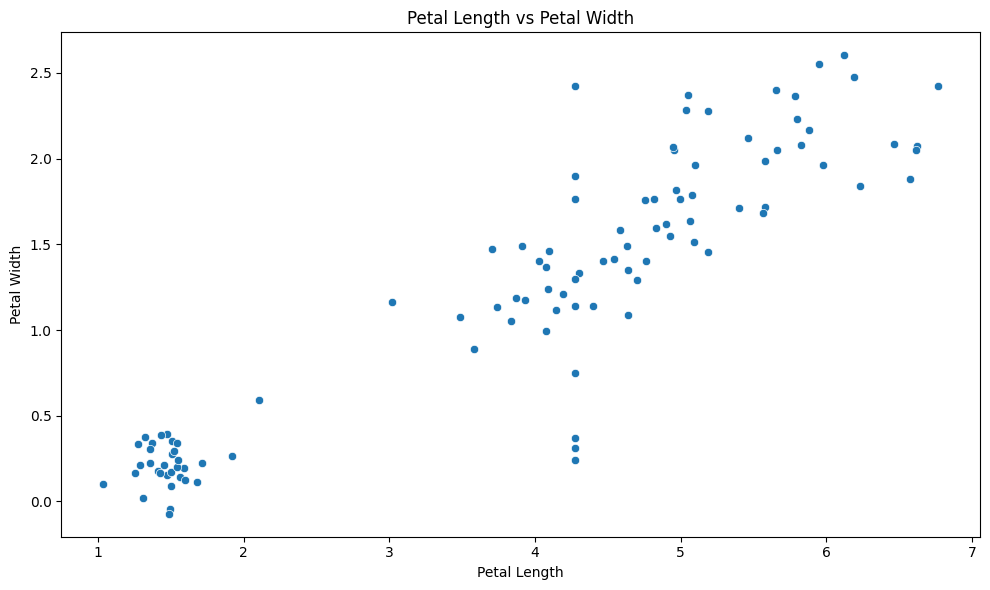

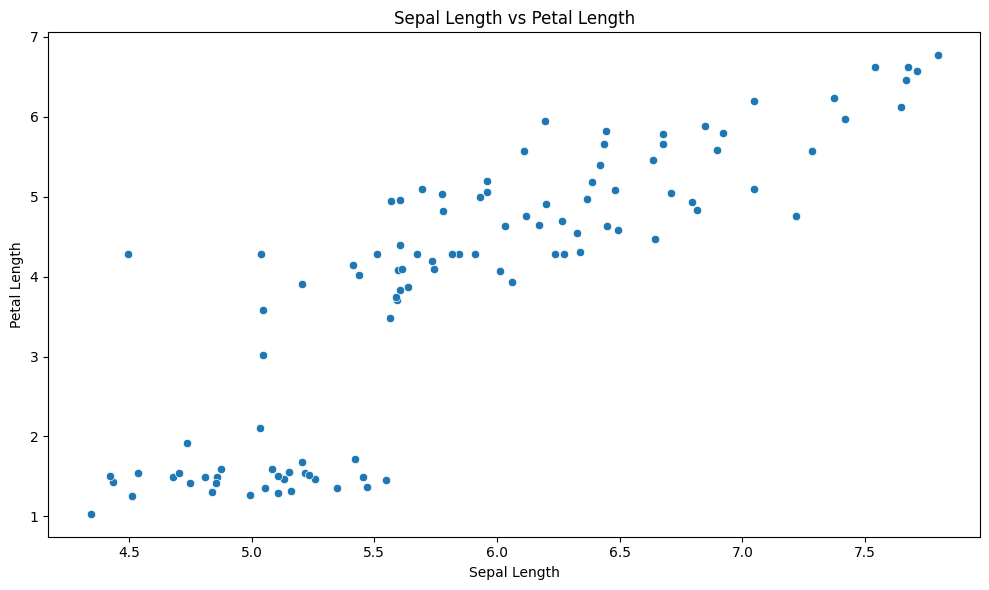

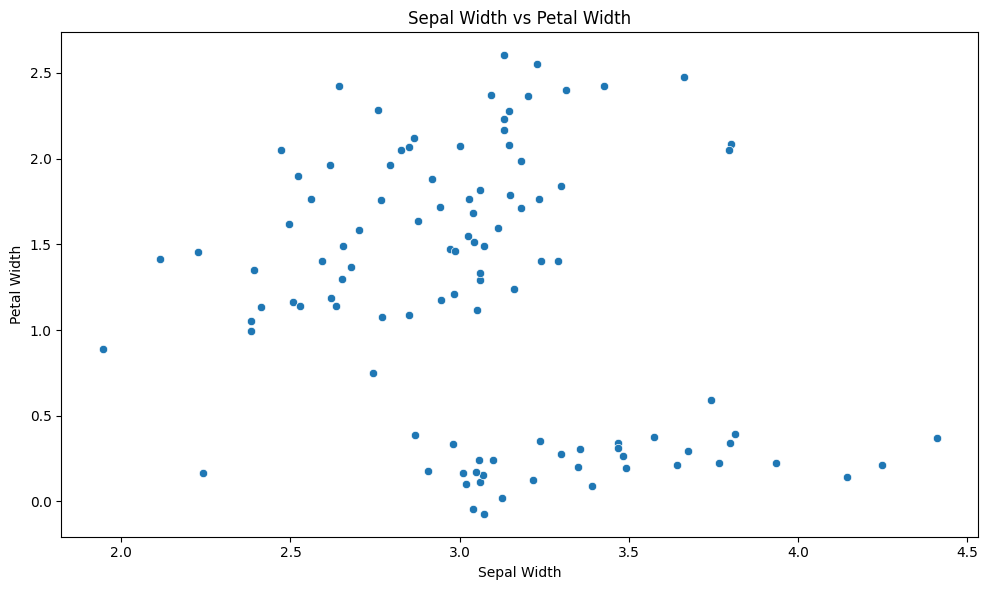

In [512]:
''' [7] EDA (Numerical/Categorical Data) '''
# Sepal Length vs. Sepal Width
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='sepal_length', y='sepal_width')
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.tight_layout()
plt.show()

# Petal Length vs. Petal Width
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='petal_length', y='petal_width')
plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.tight_layout()
plt.show()

# Sepal Length vs. Petal Length
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='sepal_length', y='petal_length')
plt.title('Sepal Length vs Petal Length')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.tight_layout()
plt.show()

# Sepal Width vs. Petal Width
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='sepal_width', y='petal_width')
plt.title('Sepal Width vs Petal Width')
plt.xlabel('Sepal Width')
plt.ylabel('Petal Width')
plt.tight_layout()
plt.show()

In [513]:
''' [8] One-hot Encoding '''

' [8] One-hot Encoding '

In [514]:
''' [9] Feature Engineering '''

' [9] Feature Engineering '

In [515]:
''' [10] Train Model '''
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X=train_df.drop(columns=['species'])
y=train_df['species']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

pipeline=Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

pipeline.fit(X_train, y_train)

predictions=pipeline.predict(X_test)

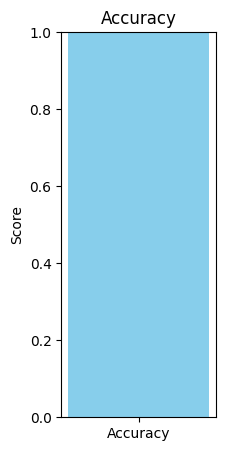

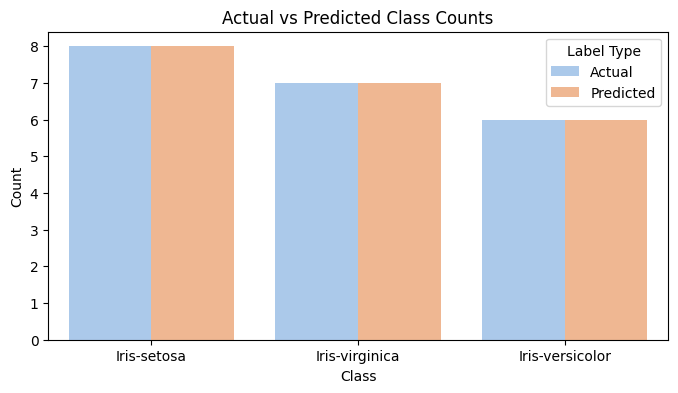

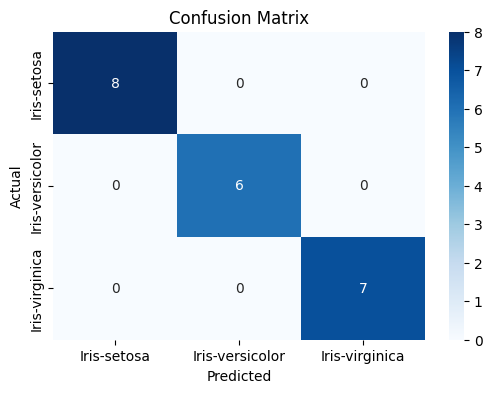

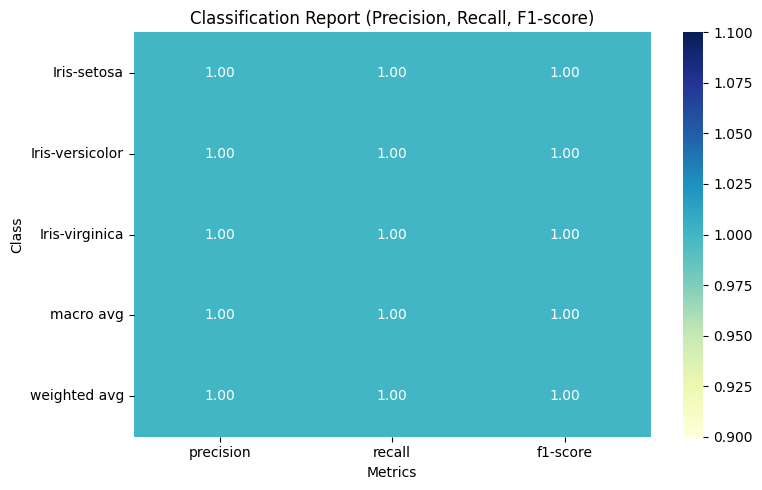

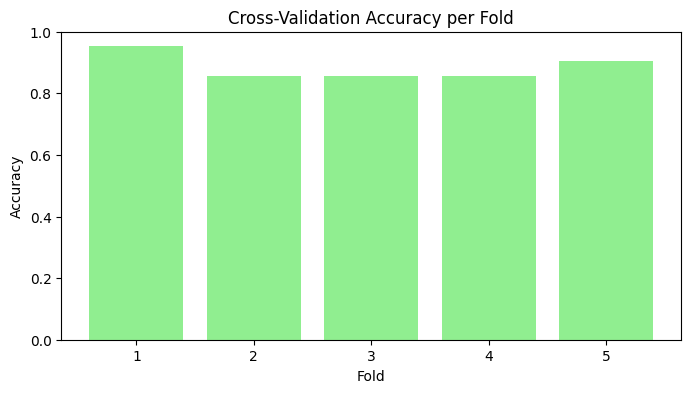

Mean CV Accuracy: 0.8857
Standard Deviation: 0.0381


In [516]:
''' [11] Evaluate Model '''
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

# 1. Accuracy - Bar Plot
accuracy = accuracy_score(y_test, predictions)

plt.figure(figsize=(2, 5))
plt.bar(["Accuracy"], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.title("Accuracy")
plt.ylabel("Score")
plt.show()

# 2. Actual vs Predicted - Bar Chart
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

plt.figure(figsize=(8, 4))
sns.countplot(
    x='value', hue='Type',
    data=pd.melt(results_df, value_vars=['Actual', 'Predicted'], var_name='Type'),
    palette='pastel'
)
plt.title("Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title='Label Type')
plt.show()

# 3. Confusion Matrix - Heatmap
cm = confusion_matrix(y_test, predictions)
labels = sorted(y.unique())  # 'species' class names

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. Classification Report - Text + Heatmap
report = classification_report(y_test, predictions, output_dict=True)

report_df = pd.DataFrame(report).drop(columns=['accuracy'], errors='ignore')

plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:3, :].T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report (Precision, Recall, F1-score)")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# 5. Cross-Validation Scores - Bar Plot
scores = cross_val_score(pipeline, X, y, cv=5)

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.show()

# Mean and standard deviation
mean_score = scores.mean()
std_score = scores.std()

print(f"Mean CV Accuracy: {mean_score:.4f}")
print(f"Standard Deviation: {std_score:.4f}")

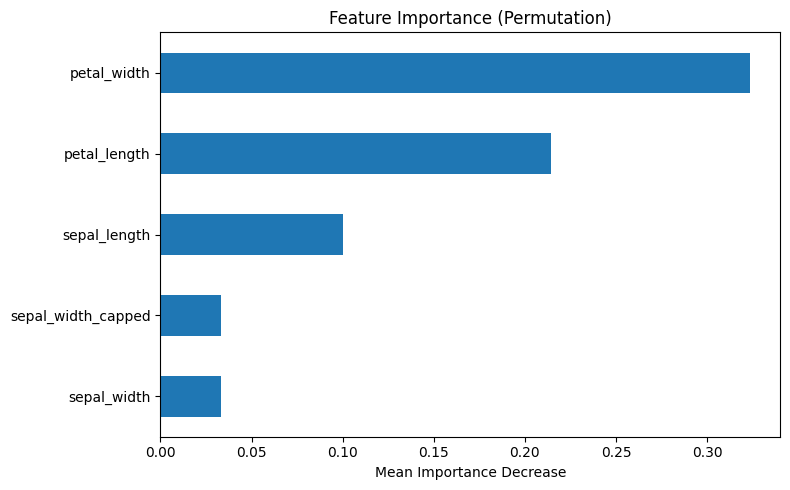

In [517]:
''' [12] Feature Importance / Model Interpretation '''
from sklearn.inspection import permutation_importance
# NOTE: KNN-specific
# Run on test data
result = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Convert to Series for plotting
importance = pd.Series(result.importances_mean, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8, 5), title="Feature Importance (Permutation)")
plt.xlabel("Mean Importance Decrease")
plt.tight_layout()
plt.show()

In [518]:
''' [13] Export Model & Results '''
import joblib
from sklearn.preprocessing import LabelEncoder

# Define the feature columns used during training
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'sepal_width_capped']

# Reuse label encoder used during training
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(train_df['species'])  # Fit on training labels

# Predict on test set
X_test_final = test_df[features]
test_predictions_str = pipeline.predict(X_test_final)

# Convert string labels to numeric labels
test_predictions = label_encoder.transform(test_predictions_str)

# Build submission DataFrame with required format
submission = pd.DataFrame({
    'id': test_df['id'],
    'species': test_predictions  # <-- Now numeric (0, 1, 2)
})

# Save submission file
submission.to_csv('iris_test_predictions.csv', index=False)

# Save pipeline
joblib.dump(pipeline, 'Iris[Species].joblib')
train_df.to_csv('iris_model.csv', index=False)